# Target Visibility Checker
- **Cell 1** — imports.  The helper functions live in `helpers.py` beside this
  notebook.
- **Cell 2** — everything you edit: `targets_list`, the UTC start/stop, the
  cadence in minutes, and the `Visibility` instance (default keep-outs).
- **Cell 3** — per-target visibility at the best fixed roll
  (`get_visibility` with `optimize_roll=True`), with a
  statistics summary and, for planets, how much of each transit and secondary
  eclipse is observable.
- **Cell 4** — one timeline for all targets: a green line wherever the target
  is visible, over blue transit and purple eclipse boxes.
- **Cell 5** — per-target breakdown of which constraint is failing while the
  target is not visible.

Name a planet rather than a star — `"WASP-107 b"`, `"TRAPPIST-1 b"` — and the
NASA Exoplanet Archive is queried for its ephemeris so transits and secondary
eclipses can be overlaid.  A trailing **lowercase** letter marks the planet; a
trailing uppercase letter is a binary component and stays part of the star
name, so `"WASP-160 B"` is a star and `"WASP-160 B b"` is its planet.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from matplotlib.patches import Patch

from helpers import (
    ECLIPSE_COLOR,
    TRANSIT_COLOR,
    build_time_grid,
    draw_event_box,
    draw_row,
    event_segments,
    event_visibility_stats,
    format_date_axis,
    label_rows,
    mask_segments,
    predict_events,
    prepare_targets,
    run_stats,
)
from pandoravisibility import Visibility, version

print(f"Pandora Visibility Version: {version}.")

Pandora Visibility Version: 2.0.0.


## Edit this cell

`targets_list` accepts star names (looked up in SIMBAD), planet names ending in
a lowercase letter (looked up in SIMBAD *and* the NASA Exoplanet Archive),
decimal-degree pairs, and sexagesimal string pairs — mix them freely.

In [2]:
# Targets
# targets_list = [
#     "GJ 1214",                       # name → looked up in SIMBAD
#     "WASP-80",
#     "TOI-836",
#     "KELT-9",                        # inside the Sun keep-out all day here
#     "WASP-107 b",                    # planet → transit + eclipse overlay
#     "WASP-107 c",                    # known planet, does not transit → warning
#     "WASP-160 B b",                  # planet of the B component of a binary
#     (255.0, 10.0),                   # RA, Dec in decimal degrees
#     ("17h00m00s", "-30d00m00s"),     # RA, Dec as sexagesimal strings
# ]

targets_list = [
    "HD209458 b",
    "WASP-69 b",
    "KELT-9 b",
    "HAT-P-67 b",
    "GJ 12 b ",
    "K2-141 b",
    # "KELT-20 b",
    # "GJ 9827 b",
    # "HD221416 b",
    # "TOI-1533 c",
    # "WASP-52 b",
    # "WASP-127 b"
]

# Time window (UTC) and cadence
start_utc = "2026-08-10T00:00:00"
stop_utc = "2026-09-30T00:00:00"
time_step_minutes = 10.0

# Spacecraft orbit
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26212.76861111  .00000000  00000-0  37770-3 0    05"
line2 = "2 67395  97.8073 210.7389 0004787   3.5990  91.5851 14.88172851    02"

# These are the class defaults as of v1.3.0, spelled out so the run stays
# pinned if the defaults move again.  Pass overrides here to change any of
# them, e.g. Visibility(line1, line2, st_required=2).
visibility = Visibility(
    line1, line2,
    earthlimb_day_min=44 * u.deg,
    earthlimb_night_min=13 * u.deg,
    sun_min=91 * u.deg,
    moon_min=20 * u.deg,
    st_sun_min=50 * u.deg,
    st_moon_min=20 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1,
    use_dynamic_earthlimb=True,
    # Sun/Moon evaluated hourly and interpolated instead of at every
    # timestep.  Their directions stay good to well under 0.01 deg, and
    # long multi-target runs get several times faster.  Drop this line to
    # evaluate the ephemeris exactly.
    ephemeris_step=60 * u.min,
)

# Roll sweep resolution for the optimize_roll search.  It only bites while
# star tracker keep-outs are active, which they are by default.
roll_step = 2 * u.deg

times = build_time_grid(start_utc, stop_utc, time_step_minutes)

print(visibility)
print(f"Orbital period: {visibility.get_period():.2f}")
print(f"{len(times)} steps of {time_step_minutes:g} min: "
      f"{times[0].iso} → {times[-1].iso}")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb=dynamic, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>
Orbital period: 96.76 min
7344 steps of 10 min: 2026-08-10 00:00:00.000 → 2026-09-29 23:50:00.000


## Visibility per target

`get_visibility` with `optimize_roll=True` picks the single best fixed roll
angle for each target — the roll observing the most time steps, ties
going to the highest mean solar power — and reports visibility at every
time step at that roll.

The roll is held over the *whole* window and chosen from exactly the time
steps given, so a run this long surveys what one held attitude could see.
An observation planned visit by visit should call `get_visibility` once per
visit instead.

For any target named as a planet, the transits and secondary eclipses falling
in the window are listed with the fraction of each event that is observable.
Events touching the edge of the window are marked `*`; only the sampled part
of those counts towards the percentage.

In [3]:
targets = prepare_targets(targets_list)
results = {}

header = (
    f"{'Target':<24}{'Visible':>13}{'Duty':>8}{'Windows':>9}{'Longest':>10}"
)
print(header)
print("-" * len(header))

for target in targets:
    label = target["label"]

    best_roll = visibility.get_visibility(
        target["coord"], times, optimize_roll=True, roll_step=roll_step,
    )
    visible = np.asarray(best_roll["visible"])
    n_windows, longest_minutes = run_stats(times, visible, time_step_minutes)

    # Transits and secondary eclipses inside the window, when this target
    # was named as a planet the archive has an ephemeris for.
    events = {}
    if target["ephemeris"] is not None:
        for kind in ("transit", "eclipse"):
            ephemeris = target["ephemeris"][kind]
            if ephemeris is not None:
                events[kind] = predict_events(ephemeris, target["coord"], times)

    results[label] = {
        "coord": target["coord"],
        "visible": visible,
        "best_roll": best_roll,
        "events": events,
    }

    print(
        f"{label:<24}"
        f"{f'{visible.sum()} / {len(times)}':>13}"
        f"{100 * visible.mean():>7.1f}%"
        f"{n_windows:>9}"
        f"{longest_minutes:>8.0f} m"
    )

print("\nRoll held per target: " + ", ".join(
    f"{label} {r['best_roll']['roll_deg'][0]:+.1f}\u00b0"
    for label, r in results.items()))

# Transit and secondary eclipse coverage
print_event_details = False
if any(result["events"] for result in results.values()):
    print("\nTransit and secondary eclipse coverage")
    for label, result in results.items():
        for kind, events in result["events"].items():
            if not events:
                print(f"  {label} — no {kind} in this window")
                continue
            stats = event_visibility_stats(events, result["visible"])
            fully = sum(1 for f in stats["fractions"] if f >= 1.0)
            print(
                f"  {label} — {stats['n_events']} {kind}s "
                f"({stats['n_full']} complete), "
                f"{100 * stats['visible_fraction']:.1f}% of {kind} time visible, "
                f"{fully} fully observable"
            )
            if print_event_details:
                for event, fraction in zip(events, stats["fractions"]):
                    edge = "*" if event["clipped"] else " "
                    print(
                        f"      {event['mid'].iso[:16]} UTC{edge} "
                        f"{event['start'].iso[11:16]}-{event['stop'].iso[11:16]}  "
                        f"{100 * fraction:5.1f}% visible"
                    )

C:\Gits\pandora-visibility\docs\helpers.py:586: UserWarning: 'GJ 12 b ': could not resolve the star (Unable to find coordinates for name 'GJ 12' in database simbad using https://cds.unistra.fr/cgi-bin/nph-sesame/S?GJ%2012); skipping it.
  prepared = [prepare_target(target) for target in targets_list]


Target                        Visible    Duty  Windows   Longest
----------------------------------------------------------------


HD209458 b                3804 / 7344   51.8%     1008      70 m


WASP-69 b                 3213 / 7344   43.8%      689      60 m


KELT-9 b                  2614 / 7344   35.6%     1447      40 m


HAT-P-67 b                 683 / 7344    9.3%      239      30 m


K2-141 b                  3593 / 7344   48.9%      674      70 m

Roll held per target: HD209458 b -158.0°, WASP-69 b -168.0°, KELT-9 b -124.0°, HAT-P-67 b +170.0°, K2-141 b -160.0°

Transit and secondary eclipse coverage
  HD209458 b — 14 transits (14 complete), 52.7% of transit time visible, 0 fully observable
  HD209458 b — 15 eclipses (15 complete), 52.3% of eclipse time visible, 0 fully observable
  WASP-69 b — 13 transits (13 complete), 42.4% of transit time visible, 0 fully observable
  WASP-69 b — 14 eclipses (14 complete), 42.3% of eclipse time visible, 0 fully observable
  KELT-9 b — 34 transits (34 complete), 36.6% of transit time visible, 0 fully observable
  KELT-9 b — 35 eclipses (35 complete), 36.1% of eclipse time visible, 0 fully observable
  HAT-P-67 b — 10 transits (10 complete), 9.1% of transit time visible, 0 fully observable
  HAT-P-67 b — 11 eclipses (11 complete), 7.8% of eclipse time visible, 0 fully observable
  K2-141 b — 182 transits (182 complete), 49.5% of

## When is each target visible?

A green line means the target clears every constraint at that time step.  Blue
boxes are transits and purple boxes are secondary eclipses, so green sitting
inside a box is an observable event.

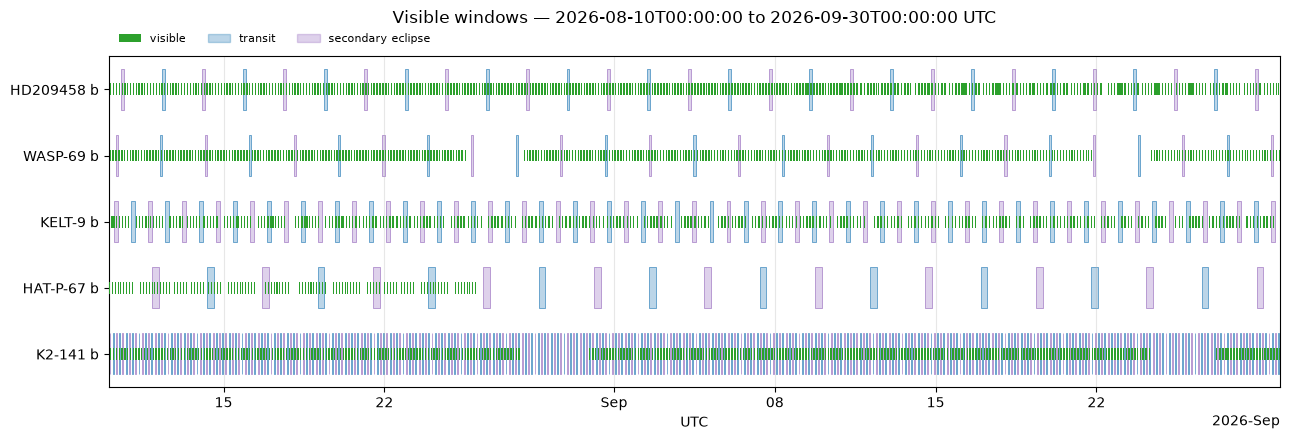

In [4]:
fig, ax = plt.subplots(figsize=(13, 0.5 * len(results) + 2.0))

for row, result in enumerate(results.values()):
    for kind, color in (("transit", TRANSIT_COLOR), ("eclipse", ECLIPSE_COLOR)):
        events = result["events"].get(kind)
        if events:
            draw_event_box(
                ax, row,
                event_segments(events, min_width_minutes=time_step_minutes),
                color,
            )
    draw_row(
        ax, row,
        mask_segments(times, result["visible"], time_step_minutes),
        "tab:green",
    )

label_rows(ax, list(results))
format_date_axis(ax, times)
ax.set_title(f"Visible windows — {start_utc} to {stop_utc} UTC", pad=24)

handles = [Patch(facecolor="tab:green", label="visible")]
if any(result["events"] for result in results.values()):
    handles += [
        Patch(facecolor=TRANSIT_COLOR, alpha=0.30, edgecolor=TRANSIT_COLOR,
              label="transit"),
        Patch(facecolor=ECLIPSE_COLOR, alpha=0.30, edgecolor=ECLIPSE_COLOR,
              label="secondary eclipse"),
    ]
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.005),
          ncols=len(handles), fontsize=8, frameon=False)
plt.tight_layout()

## Which constraint is failing?

For each target, a bar marks the time steps where that row fails; the grey
row at the bottom is the overall "not visible" result for comparison.

**Red rows are binding** — the step is lost when one of them fails.
**Amber rows are per-tracker detail** from `get_star_tracker_breakdown`:
which star tracker is failing which keep-out, and by how many steps.  With
`st_required=1` a single tracker failing is *not* fatal, because the other
one can cover it, so only the red `star tracker` row underneath is binding.
Set `st_required=2` and every amber row becomes binding.  The amber rows
share their geometry with the red `star tracker` row, so ANDing one
tracker's amber rows always reproduces that tracker's overall verdict.

Both diagnostics are asked for the roll angle the run actually used, straight
from `best_roll["roll_deg"]`.  That matters for the star tracker rows: left
to their default they use the Sun-constrained attitude, recomputed at every
step, while the run held the single roll it chose.  Two attitudes means two
tracker geometries, and the rows would then disagree with the grey one in
both directions.  Given the same roll, the red rows reproduce the grey row
exactly, so every lost step is accounted for.

Even when the boresight is blocked for the whole window, the search still
settles on a fallback attitude (best for the trackers alone, then best lit),
so the tracker rows stay meaningful: they show which tracker would have
failed, rather than going blank for want of an attitude.

HD209458 b: not visible at 3540 of 7344 steps
    moon           fails at     0 steps
    sun            fails at     0 steps
    earthlimb      fails at  3080 steps
    star tracker   fails at  2107 steps  (needs either tracker)
      ST1            fails at  3914 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3914 steps
      ST2            fails at  3920 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3920 steps


WASP-69 b: not visible at 4131 of 7344 steps
    moon           fails at   721 steps
    sun            fails at     0 steps
    earthlimb      fails at  3573 steps
    star tracker   fails at  2141 steps  (needs either tracker)
      ST1            fails at  3958 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3958 steps
      ST2            fails at  3921 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3921 steps


KELT-9 b: not visible at 4730 of 7344 steps
    moon           fails at     0 steps
    sun            fails at     0 steps
    earthlimb      fails at  2949 steps
    star tracker   fails at  2008 steps  (needs either tracker)
      ST1            fails at  3926 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3926 steps
      ST2            fails at  3931 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3931 steps


HAT-P-67 b: not visible at 6661 of 7344 steps
    moon           fails at     0 steps
    sun            fails at  5030 steps
    earthlimb      fails at  3435 steps
    star tracker   fails at  3644 steps  (needs either tracker)
      ST1            fails at  6239 steps
        sun        < 50 deg at  4920 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  4099 steps
      ST2            fails at  3958 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3958 steps


K2-141 b: not visible at 3751 of 7344 steps
    moon           fails at   872 steps
    sun            fails at     0 steps
    earthlimb      fails at  3238 steps
    star tracker   fails at  2010 steps  (needs either tracker)
      ST1            fails at  3916 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3916 steps
      ST2            fails at  3969 steps
        sun        < 50 deg at     0 steps
        moon       < 20 deg at     0 steps
        limb       < 30 deg at  3969 steps


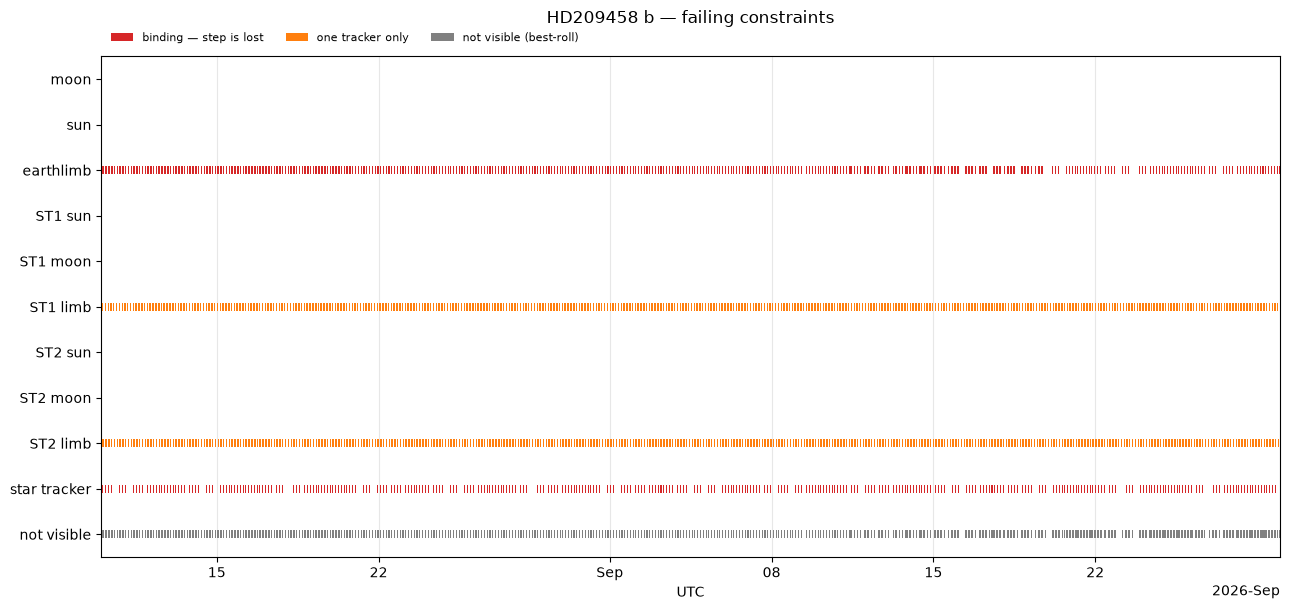

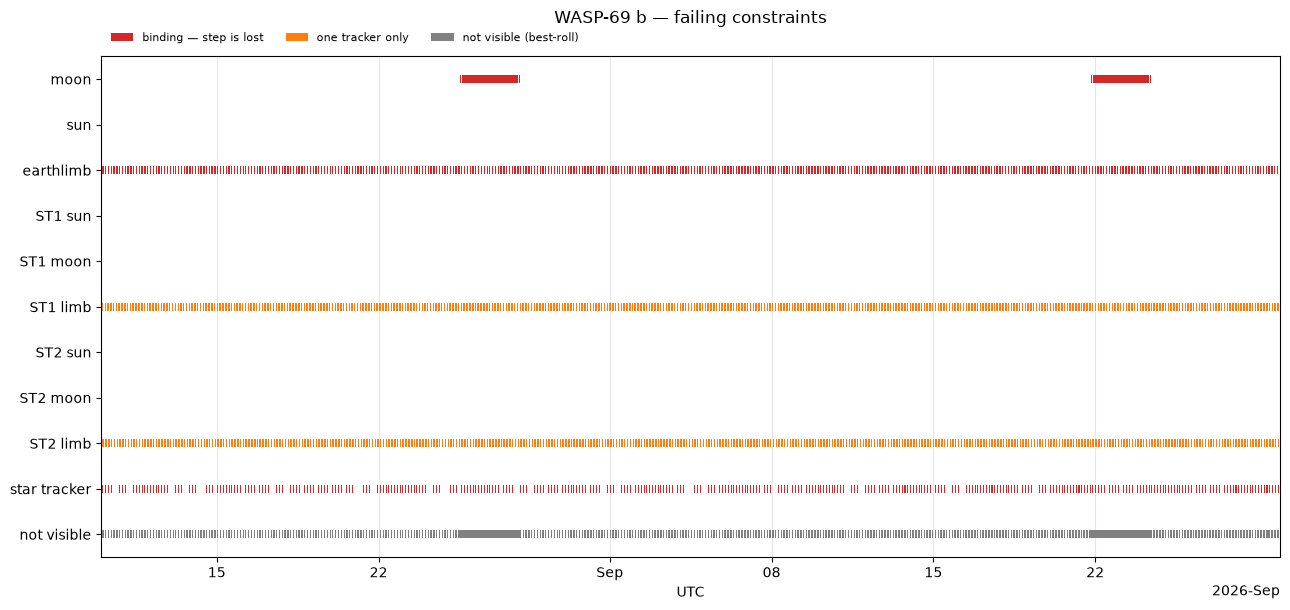

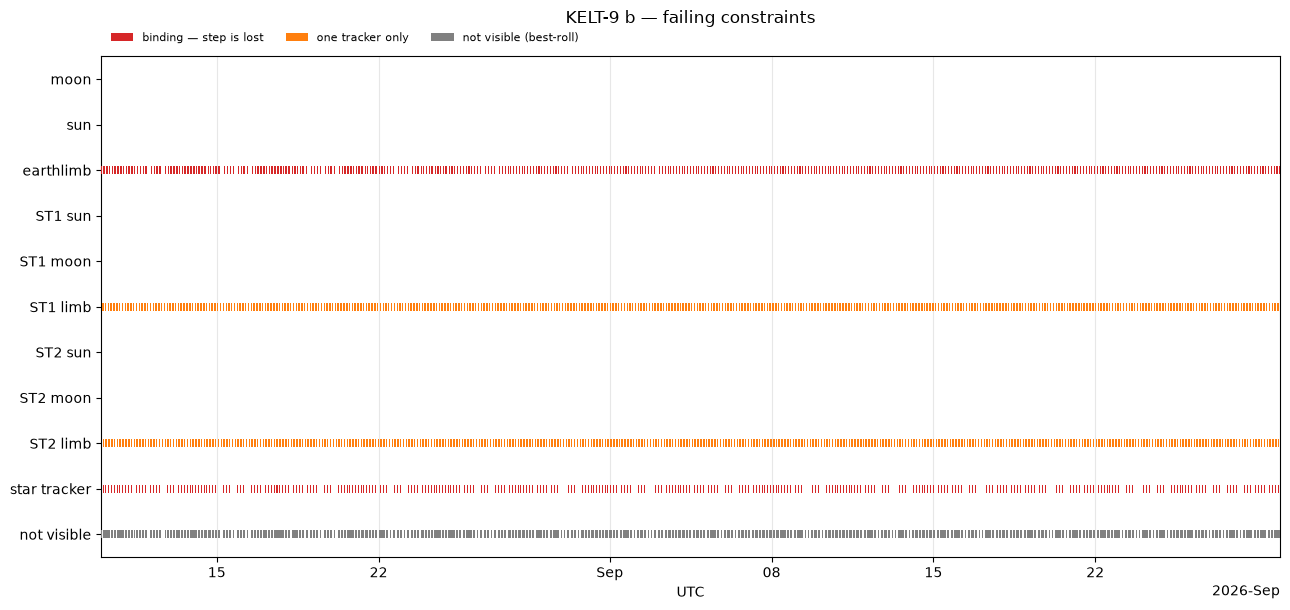

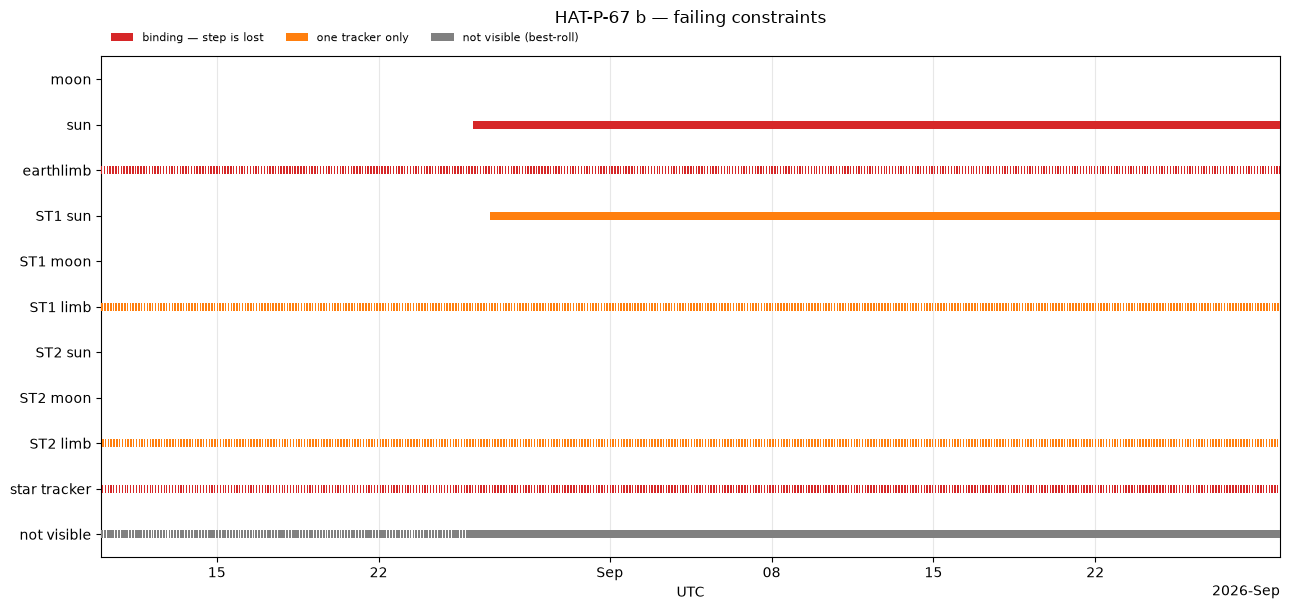

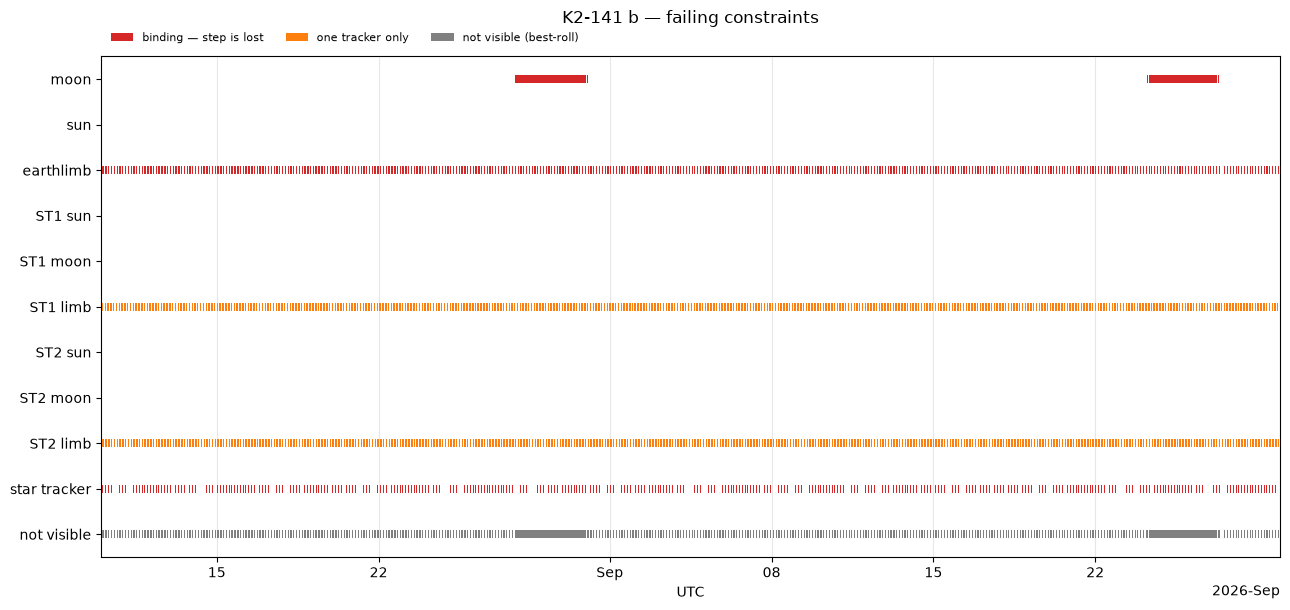

In [5]:
# Red marks a binding constraint: it failing is enough to lose the step.
# Amber marks one tracker failing one keep-out, which is only binding when
# no other tracker covers it — with st_required=1 the binding row is the
# combined "star tracker" one underneath.
BINDING_COLOR = "tab:red"
TRACKER_COLOR = "tab:orange"

for label, result in results.items():
    # The roll the run actually held, straight from its result. Without
    # it the tracker rows describe the default Sun-constrained attitude
    # rather than the one the run flew, and stop matching the result.
    run_roll = result["best_roll"]["roll_deg"] * u.deg

    constraints = visibility.get_all_constraints(
        result["coord"], times, roll=run_roll
    )
    breakdown = visibility.get_star_tracker_breakdown(
        result["coord"], times, roll=run_roll
    )
    not_visible = ~result["visible"]

    # Binding rows: the boresight bodies, plus the combined star tracker
    # verdict when trackers are active.
    binding = {
        name.replace("_", " "): ~np.asarray(passed)
        for name, passed in constraints.items()
    }
    # Per-tracker detail: one row per active check per tracker.  Shares
    # its geometry with the combined verdict above, so the rows always
    # add up.
    detail = {
        name: ~np.asarray(ok)
        for name, ok in breakdown["passed"].items()
        if name not in ("ST1", "ST2", "combined")
    }

    # "not visible" is explained by the binding rows only.
    explained = np.zeros_like(not_visible)
    for fail_mask in binding.values():
        explained |= fail_mask
    unexplained = int(np.sum(not_visible & ~explained))

    boresight = [n for n in binding if n != "star tracker"]
    st_rows = ["star tracker"] if "star tracker" in binding else []
    rows = boresight + list(detail) + st_rows + ["not visible"]

    fig, ax = plt.subplots(figsize=(13, 0.4 * len(rows) + 1.8))
    for row, name in enumerate(rows):
        if name == "not visible":
            mask, color = not_visible, "0.5"
        elif name in detail:
            mask, color = detail[name], TRACKER_COLOR
        else:
            mask, color = binding[name], BINDING_COLOR
        draw_row(ax, row, mask_segments(times, mask, time_step_minutes), color)

    label_rows(ax, rows)
    format_date_axis(ax, times)
    # The legend sits just above the axes, so lift the title clear of it —
    # same treatment as the visible-windows plot above.
    ax.set_title(f"{label} — failing constraints", pad=24 if detail else 6)
    if detail:
        handles = [
            Patch(facecolor=BINDING_COLOR, label="binding — step is lost"),
            Patch(facecolor=TRACKER_COLOR, label="one tracker only"),
            Patch(facecolor="0.5", label="not visible (best-roll)"),
        ]
        ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.0, 1.005),
                  ncols=len(handles), fontsize=8, frameon=False)
    plt.tight_layout()

    print(f"{label}: not visible at {int(not_visible.sum())} of {len(times)} steps")
    for name in boresight:
        print(f"    {name:<14} fails at {int(binding[name].sum()):>5} steps")

    if detail:
        need = "both trackers" if visibility.st_required == 2 else "either tracker"
        print(f"    {'star tracker':<14} fails at "
              f"{int(binding['star tracker'].sum()):>5} steps  (needs {need})")
        for tracker in (1, 2):
            overall = ~np.asarray(breakdown["passed"][f"ST{tracker}"])
            print(f"      ST{tracker}{'':<11} fails at {int(overall.sum()):>5} steps")
            for name, mask in detail.items():
                if not name.startswith(f"ST{tracker} "):
                    continue
                check = name.split(" ", 1)[1]
                limit = breakdown["limits"][name]
                print(f"        {check:<10} < {limit.value:.0f} deg at "
                      f"{int(mask.sum()):>5} steps")

    if unexplained:
        print(f"    WARNING: {unexplained} not-visible steps are not explained "
              f"by any row above; the rows and the result have diverged")